# 03 - Results analysis

All numbers come from `results/tables/` (written by the experiment scripts). This notebook does not train anything. It puts the tables side by side and adds a few checks that are easier to do interactively: seed variance, paired significance tests, and how the conclusions change per user group.

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

T = "../results/tables/"
F = "../results/figures/"
pd.set_option("display.width", 200)
main = pd.read_csv(T + "main_results.csv")
cols = ["model", "recall@10", "recall@20", "recall@20_std", "ndcg@10", "ndcg@20", "precision@10", "map@20", "mrr",
        "coverage@10", "n_seeds"]
main[cols].round(4)

,model,recall@10,recall@20,recall@20_std,ndcg@10,ndcg@20,precision@10,map@20,mrr,coverage@10,n_seeds
0,Popularity,0.0601,0.1004,NaN,0.2958,0.2726,0.2775,0.1527,0.4893,0.0318,1
1,Popularity (recent),0.0662,0.1118,NaN,0.2947,0.2793,0.2751,0.1552,0.4935,0.0262,1
2,Popularity (demographic),0.0664,0.1097,NaN,0.3072,0.2873,0.2866,0.1626,0.5028,0.0456,1
3,ItemKNN,0.0669,0.1110,NaN,0.3178,0.2934,0.2963,0.1670,0.5233,0.0920,1
4,MF-BPR,0.0697,0.1143,0.0023,0.3186,0.2948,0.2954,0.1683,0.5147,0.1256,3
5,Two-Tower,0.0692,0.1177,0.0027,0.2988,0.2827,0.2797,0.1557,0.4839,0.1969,3
6,Node2Vec,0.0616,0.1040,0.0043,0.2832,0.2637,0.2629,0.1460,0.4749,0.2140,3
7,GraphSAGE,0.0669,0.1123,0.0010,0.3085,0.2885,0.2860,0.1613,0.5081,0.1664,3
8,GAT,0.0667,0.1139,0.0017,0.3066,0.2861,0.2847,0.1590,0.5032,0.2080,3
9,LightGCN,0.0712,0.1209,0.0016,0.3183,0.2982,0.2952,0.1677,0.5198,0.1597,3


LightGCN and the LightGCN-based hybrid are the best single models on recall@20 (0.121 and 0.122). MF, LightGCN, the hybrid and ItemKNN are practically tied on NDCG@10. The two-tower model finds more targets (third in recall) but orders the first positions worse (lowest NDCG@10 among the learned models apart from Node2Vec). Recent popularity is within 0.003 of MF, so the baselines are not weak.

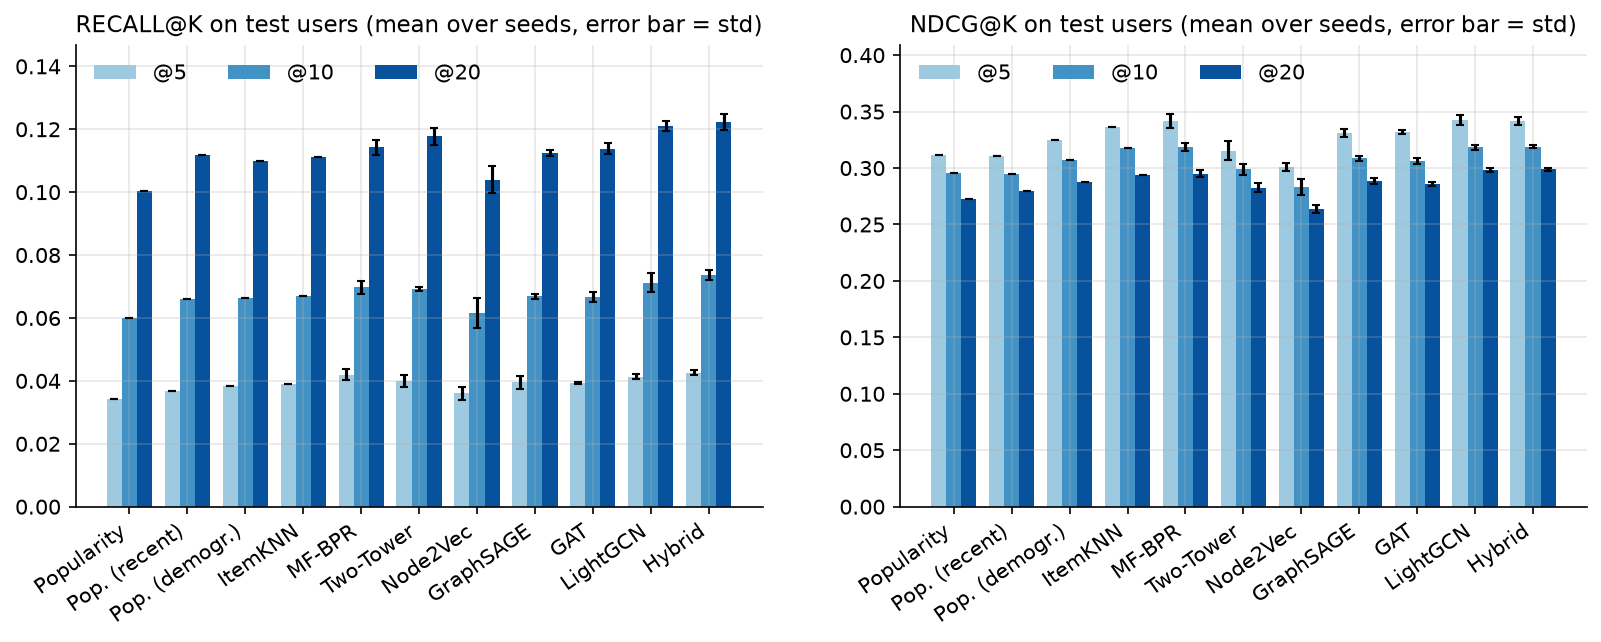

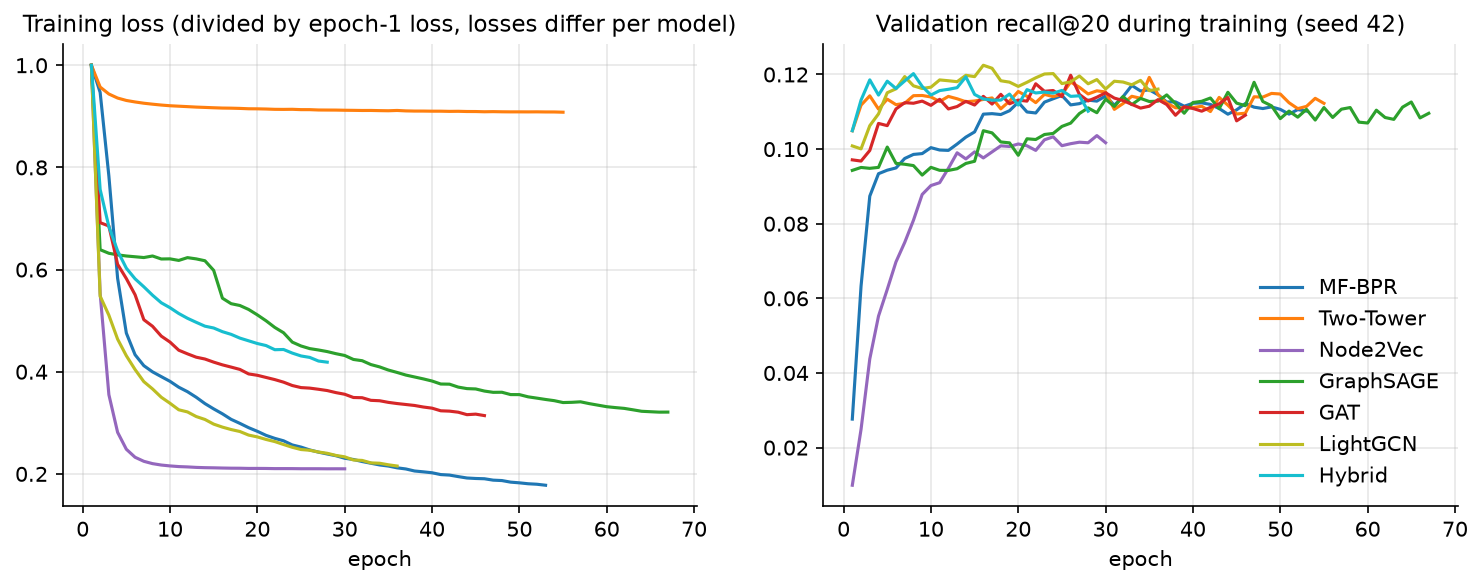

In [2]:
display(Image(F + "main_recall_ndcg_at_k.png"))
display(Image(F + "training_curves.png"))

## Is the difference real? Paired tests on the same test users

In [3]:
sig = pd.read_csv(T + "significance_tests.csv")
sig[sig["users"] == "all"][["model_a", "model_b", "mean_recall@20_a", "mean_recall@20_b", "diff", "ci95_low", "ci95_high",
                            "wilcoxon_p", "a_better_users", "b_better_users"]].round(4)

,model_a,model_b,mean_recall@20_a,mean_recall@20_b,diff,ci95_low,ci95_high,wilcoxon_p,a_better_users,b_better_users
0,LightGCN,MF-BPR,0.1209,0.1143,0.0066,0.0030,0.0103,0.0001,313,242
4,GraphSAGE,MF-BPR,0.1123,0.1143,-0.0020,-0.0063,0.0021,0.8282,286,299
8,GAT,MF-BPR,0.1139,0.1143,-0.0004,-0.0050,0.0040,0.3648,294,314
12,GAT,GraphSAGE,0.1139,0.1123,0.0015,-0.0024,0.0054,0.9722,311,315
16,Node2Vec,MF-BPR,0.1040,0.1143,-0.0103,-0.0151,-0.0057,0.0000,302,358
20,Hybrid (id+content+graph),LightGCN,0.1224,0.1209,0.0015,-0.0027,0.0060,0.8193,349,338
24,Two-Tower,MF-BPR,0.1177,0.1143,0.0035,-0.0020,0.0091,0.5444,341,372
28,ItemKNN,MF-BPR,0.1110,0.1143,-0.0032,-0.0076,0.0012,0.2292,315,342
32,Final pipeline,Hybrid (id+content+graph),0.1325,0.1224,0.0101,0.0060,0.0145,0.0000,408,288
36,Final pipeline,LightGCN,0.1325,0.1209,0.0116,0.0065,0.0172,0.0005,379,301


With per-user recall averaged over the three seeds, LightGCN vs. MF (+0.0066) is the only graph-vs-MF difference whose confidence interval excludes zero. GraphSAGE and GAT are indistinguishable from MF and from each other, Node2Vec is significantly worse. The content in the hybrid does not add a significant amount on top of LightGCN. The LightGCN advantage holds for warm users and is largest for the 73 sparse users, and it is zero for cold users (both models fall back to the same kind of unknown-user vector).

In [4]:
sig[(sig["model_a"] == "LightGCN") & (sig["model_b"] == "MF-BPR")].round(4)

,model_a,model_b,users,n,mean_recall@20_a,mean_recall@20_b,diff,ci95_low,ci95_high,wilcoxon_p,a_better_users,b_better_users
0,LightGCN,MF-BPR,all,881,0.1209,0.1143,0.0066,0.0030,0.0103,0.0001,313,242
1,LightGCN,MF-BPR,warm,487,0.1249,0.1168,0.0081,0.0023,0.0136,0.0003,196,144
2,LightGCN,MF-BPR,sparse,73,0.1327,0.1067,0.0261,0.0067,0.0499,0.0359,35,24
3,LightGCN,MF-BPR,cold,321,0.1121,0.1122,-0.0001,-0.0009,0.0007,0.6203,82,74


## Per user group

In [5]:
g = main[["model"] + [f"{x}/recall@20" for x in ("warm", "sparse", "cold")]].set_index("model").round(4)
g["warm minus cold"] = (g["warm/recall@20"] - g["cold/recall@20"]).round(4)
g

,warm/recall@20,sparse/recall@20,cold/recall@20,warm minus cold
model,,,,
Popularity,0.0927,0.0900,0.1144,-0.0217
Popularity (recent),0.1116,0.0895,0.1171,-0.0055
Popularity (demographic),0.1055,0.0983,0.1188,-0.0133
ItemKNN,0.1081,0.1161,0.1144,-0.0063
MF-BPR,0.1168,0.1067,0.1122,0.0046
Two-Tower,0.1209,0.1314,0.1098,0.0111
Node2Vec,0.1096,0.0174,0.1152,-0.0056
GraphSAGE,0.1115,0.1119,0.1136,-0.0021
GAT,0.1150,0.1131,0.1123,0.0027


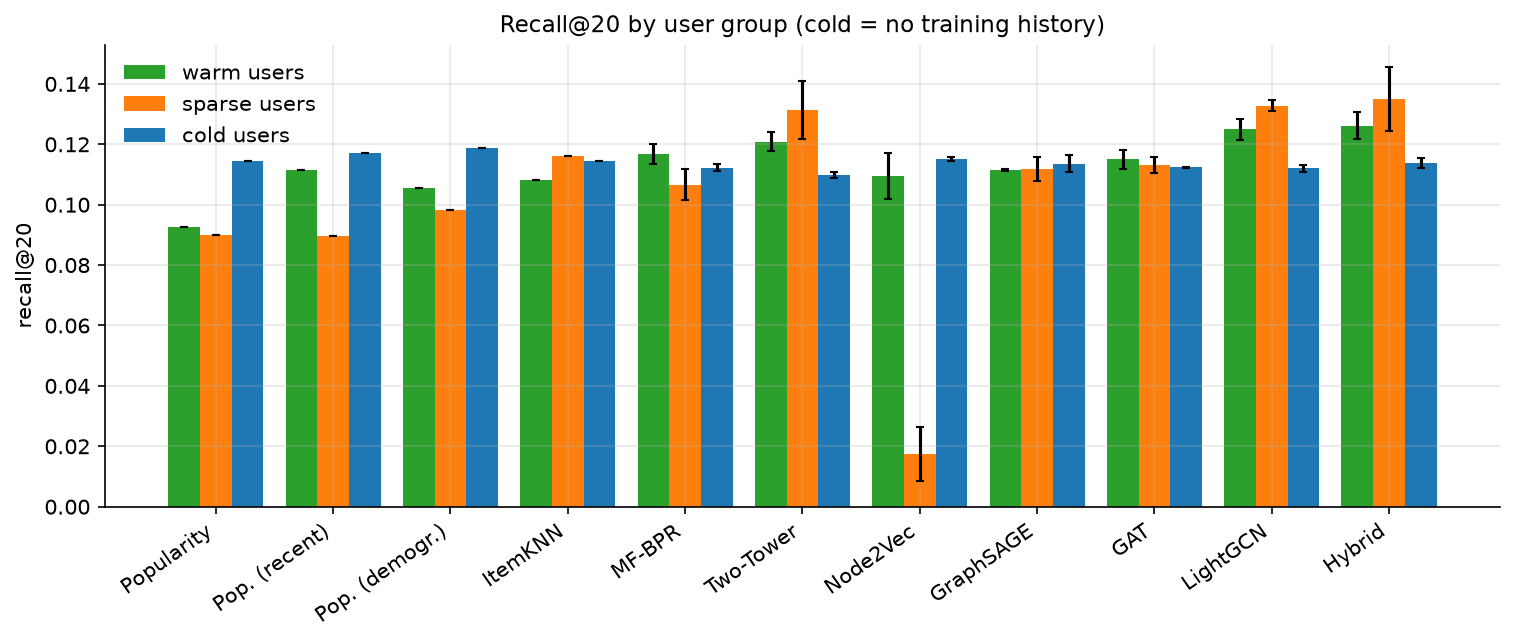

In [6]:
display(Image(F + "cold_start_user_groups.png"))

The cold column is almost flat: every model lands between 0.110 and 0.119, and the simplest one (demographic popularity) is the best. The learned models only separate from the popularity baselines on users that have a history.

## Cold-start: new items and new users

In [7]:
pd.read_csv(T + "item_cold_results.csv")[["model", "coldtgt/recall@20_among_new", "coldtgt/ndcg@20_among_new",
                                           "coldtgt/recall@100_full_catalog", "cold_item_share_in_top20", "test/recall@20"]].round(4)

,model,coldtgt/recall@20_among_new,coldtgt/ndcg@20_among_new,coldtgt/recall@100_full_catalog,cold_item_share_in_top20,test/recall@20
0,Popularity,0.0358,0.0218,0.0000,0.0000,0.0975
1,ItemKNN,0.0358,0.0218,0.0000,0.0000,0.1082
2,MF-BPR,0.0483,0.0306,0.0000,0.0000,0.1140
3,Two-Tower,0.1260,0.0796,0.0380,0.0469,0.1073
4,Node2Vec,0.0379,0.0242,0.0087,0.0353,0.0995
5,GraphSAGE,0.0373,0.0279,0.0000,0.0000,0.1071
6,GAT,0.0437,0.0280,0.0000,0.0000,0.1123
7,LightGCN,0.0507,0.0386,0.0000,0.0000,0.1154
8,Hybrid (id+content+graph),0.1356,0.1064,0.0017,0.0001,0.1185
9,Content + graph (no id),0.1104,0.0701,0.0021,0.0005,0.1101


In [8]:
ob = pd.read_csv(T + "onboarding_results.csv")
ob.pivot(index="model", columns="k_revealed", values="recall@20").round(4)

k_revealed,0,1,3,5,10
model,,,,,
GAT,0.0951,0.0812,0.0859,0.1099,0.1264
GraphSAGE,0.0997,0.0657,0.0947,0.1081,0.1193
Hybrid (id+content+graph),0.0975,0.0980,0.0970,0.1012,0.1056
ItemKNN,0.0986,0.0741,0.0847,0.0992,0.1260
LightGCN,0.0957,0.0933,0.0933,0.0956,0.1007
MF-BPR,0.0951,0.0812,0.0871,0.1006,0.1214
Node2Vec,0.0976,0.0781,0.0804,0.1026,0.1241
Popularity,0.0986,0.0986,0.0986,0.0986,0.0986
Popularity (demographic),0.1007,0.1007,0.1007,0.1007,0.1007


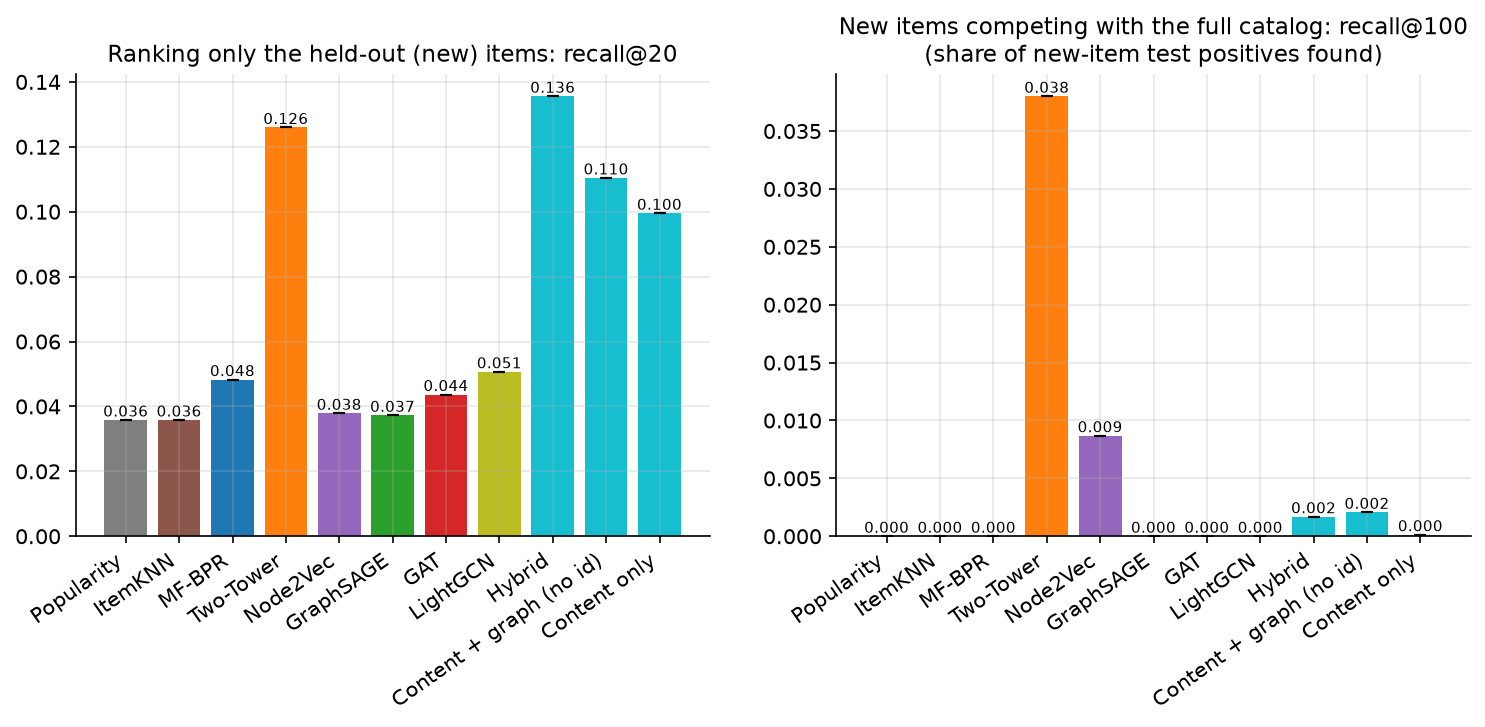

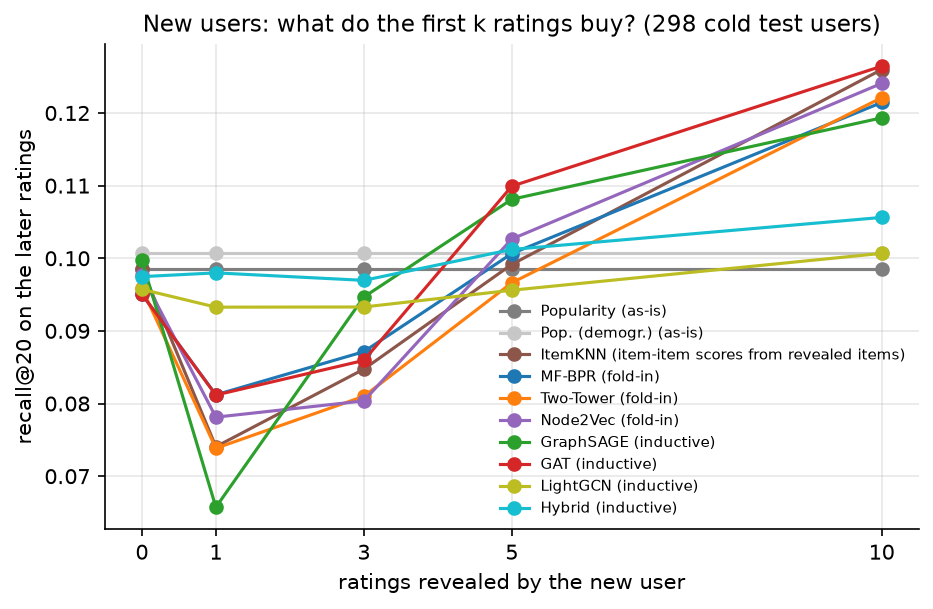

In [9]:
display(Image(F + "cold_start_items.png"))
display(Image(F + "cold_start_onboarding.png"))

Three different cold-start problems, three different answers. Users without history: nothing beats demographic popularity. New items: only the content models (hybrid, two-tower) can order them sensibly, but none of the models put them into the top of the full ranking. New users with a few ratings: one rating hurts, from about 5 ratings the personalized models overtake popularity, and the inductive GAT and plain ItemKNN use 10 ratings best. LightGCN and the hybrid hardly react, `onboarding_vector_shift.csv` shows their new-user vector stays at cosine ~0.99 with the cold vector.

## Sparse training data

In [10]:
sp = pd.read_csv(T + "sparsity_results.csv")
piv = sp.pivot(index="model", columns="train_fraction", values="recall@20")
rel = piv.div(piv[1.0], axis=0)
pd.concat({"recall@20": piv.round(4), "relative to 100%": rel.round(3)}, axis=1)

recall@20                         relative to 100%                   
train_fraction                  0.1     0.2     0.5     1.0              0.1    0.2    0.5  1.0
model                                                                                          
GAT                          0.0975  0.1043  0.1121  0.1139            0.857  0.916  0.985  1.0
GraphSAGE                    0.0958  0.0995  0.0994  0.1123            0.853  0.886  0.885  1.0
Hybrid (id+content+graph)    0.1072  0.1116  0.1166  0.1224            0.876  0.912  0.953  1.0
ItemKNN                      0.0823  0.0955  0.1074  0.1110            0.741  0.860  0.967  1.0
LightGCN                     0.0999  0.1091  0.1163  0.1209            0.827  0.902  0.962  1.0
MF-BPR                       0.0888  0.0974  0.1106  0.1143            0.777  0.853  0.968  1.0
Node2Vec                     0.0755  0.0886  0.0992  0.1040            0.726  0.852  0.954  1.0
Popularity                   0.0982  0.1000  0.1014  0.1004            0.978  0.996  1.010  1.0
Two-Tower                    0.0960  0.1012  0.1130  0.1177            0.816  0.859  0.960  1.0

In [11]:
sp.pivot(index="model", columns="train_fraction", values="warm/recall@20").round(4)

train_fraction,0.1,0.2,0.5,1.0
model,,,,
GAT,0.0929,0.1016,0.1143,0.1150
GraphSAGE,0.0881,0.0947,0.0957,0.1115
Hybrid (id+content+graph),0.1037,0.1099,0.1177,0.1262
ItemKNN,0.0637,0.0868,0.1041,0.1081
LightGCN,0.0938,0.1078,0.1179,0.1249
MF-BPR,0.0758,0.0906,0.1106,0.1168
Node2Vec,0.0589,0.0805,0.1006,0.1096
Popularity,0.0904,0.0923,0.0941,0.0927
Two-Tower,0.0910,0.0987,0.1148,0.1209


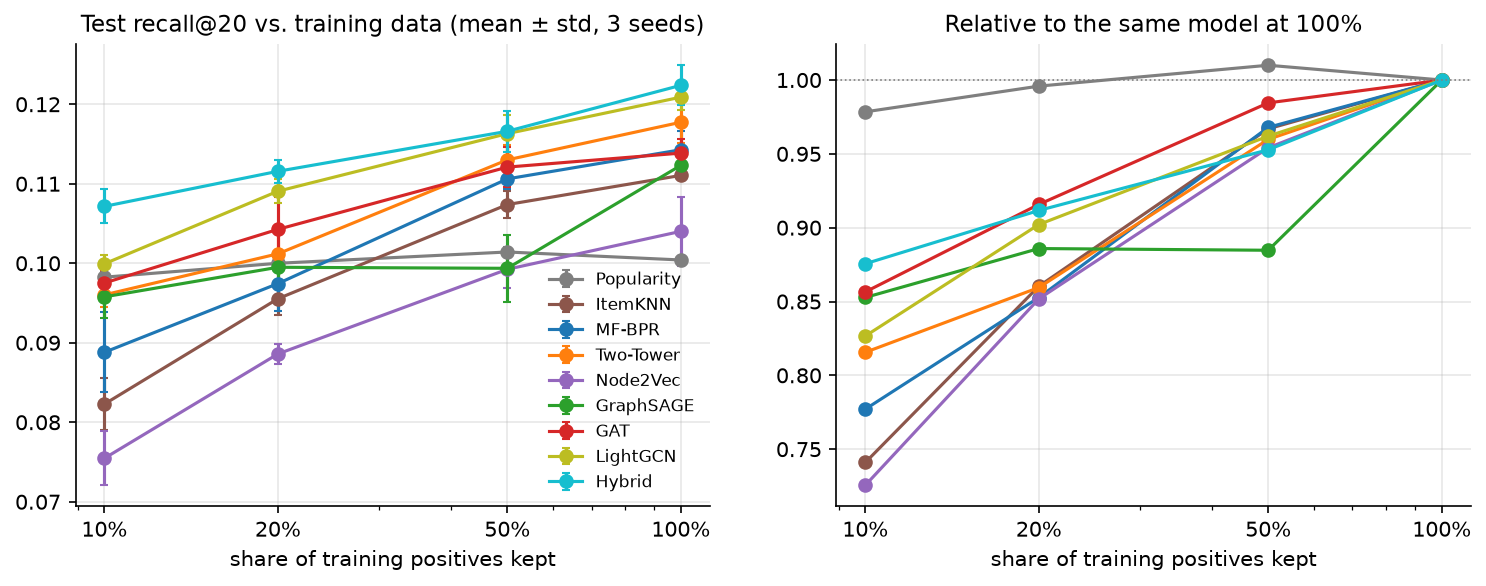

In [12]:
display(Image(F + "sparsity_curve.png"))

Relative to their own full-data result, MF and ItemKNN lose about a quarter of their recall at 10% of the data, the GNNs lose 12-17%, Node2Vec 27%. In absolute terms, at 10% only the hybrid (0.107) and LightGCN (0.100) are above all-time popularity (0.098). The GraphSAGE dip at 50% comes from one seed that early-stopped on the initial plateau.

## Hybrid ablation

In [13]:
pd.read_csv(T + "hybrid_results.csv")[["variant", "recall@20", "recall@20_std", "warm/recall@20", "sparse/recall@20",
                                        "cold/recall@20", "coverage@10", "n_params"]].round(4)

,variant,recall@20,recall@20_std,warm/recall@20,sparse/recall@20,cold/recall@20,coverage@10,n_params
0,"collaborative only (id, no graph)",0.1140,0.0004,0.1159,0.1162,0.1107,0.1981,623872.0
1,"content only (no id, no graph)",0.0927,0.0020,0.0904,0.0849,0.0978,0.0522,13952.0
2,id + content (no graph),0.1120,0.0019,0.1141,0.1194,0.1071,0.1637,637824.0
3,graph only (id + graph),0.1209,0.0016,0.1249,0.1327,0.1121,0.1597,623872.0
4,content + graph (no id),0.1157,0.0008,0.1163,0.1106,0.1161,0.0969,13952.0
5,hybrid (id + content + graph),0.1216,0.0030,0.1249,0.1291,0.1148,0.1439,637824.0


Same code, loss and budget for all six variants. Message passing is what adds accuracy (+0.007 over 'collaborative only'). Content does not add anything once the graph is there, content alone is worse than popularity. 'Content + graph' without ids is the best learned model for cold users but still below demographic popularity.

## GNN design choices

In [14]:
ga = pd.read_csv(T + "gnn_ablation_runs.csv")
ga[["base", "variant", "val/recall@20", "test/recall@20", "test/warm/recall@20", "test/cold/recall@20", "best_epoch"]].round(4)

,base,variant,val/recall@20,test/recall@20,test/warm/recall@20,test/cold/recall@20,best_epoch
0,graphsage,target edges kept in message passing,0.1158,0.1118,0.1155,0.1105,51
1,graphsage,unknown-user row trained with edges (no cold s...,0.1154,0.1110,0.1108,0.1103,47
2,graphsage,no unknown-user embedding (id dropout 0),0.1136,0.1083,0.1112,0.1047,32
3,graphsage,2 layers (patience 50),0.1160,0.1140,0.1166,0.1105,82
4,graphsage,3 layers (patience 50),0.1138,0.1106,0.1099,0.1115,52
5,graphsage,max aggregation,0.1165,0.1097,0.1100,0.1092,23
6,graphsage,jk=last,0.1147,0.1099,0.1096,0.1108,34
7,gat,target edges kept in message passing,0.1141,0.1139,0.1147,0.1107,11
8,gat,unknown-user row trained with edges (no cold s...,0.1019,0.1014,0.1171,0.0713,22
9,gat,2 layers (patience 50),0.1184,0.1195,0.1230,0.1131,38


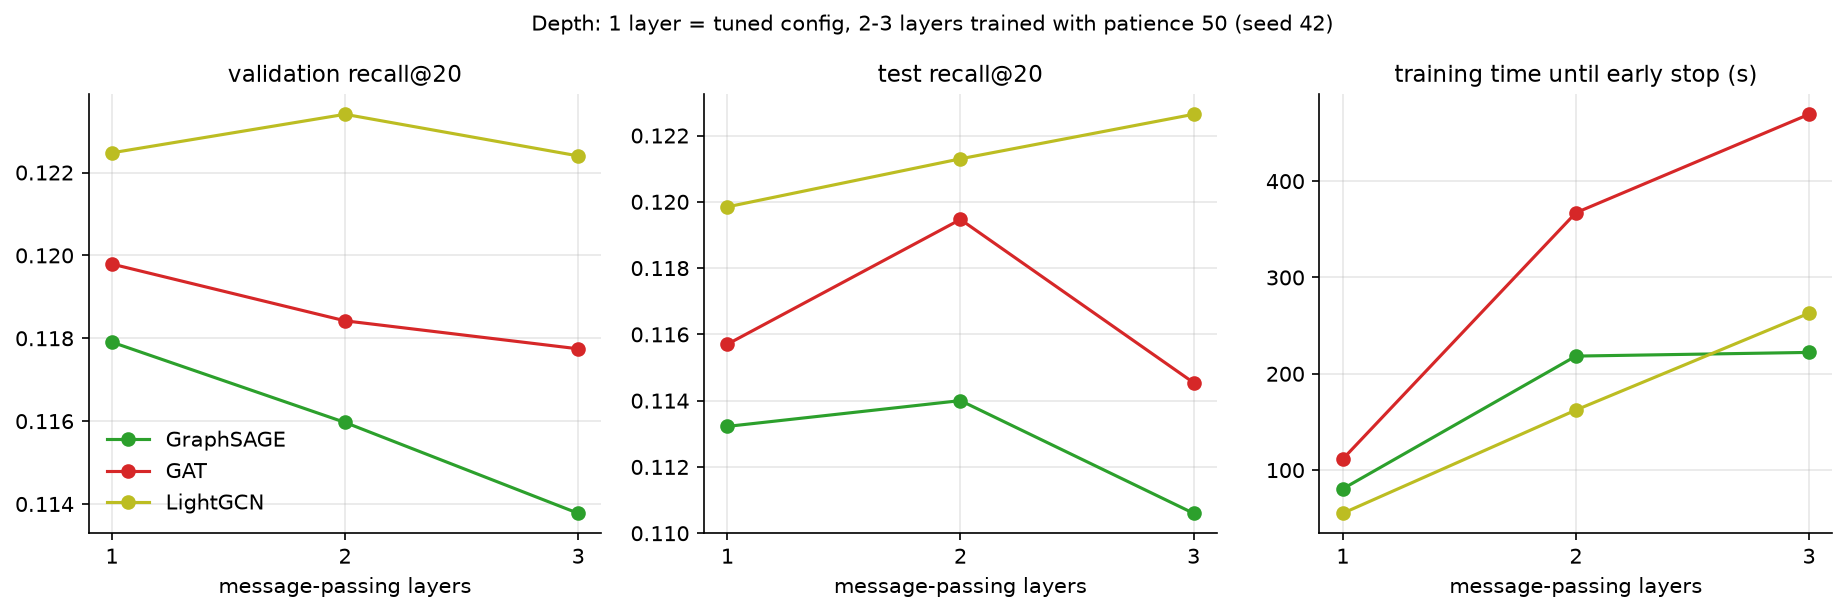

In [15]:
display(Image(F + "gnn_depth_comparison.png"))

The 'no cold simulation' rows show the bug from the diagnostics: GAT drops to 0.071 on cold users, LightGCN is unaffected. Depth: with patience 50, 2 and 3 layers are within ~0.002 of 1 layer on validation; on the single-seed test numbers the deeper LightGCN variants are slightly higher. Target-edge removal makes no measurable difference with one layer.

## Retrieval, ranking and the temporal check

In [16]:
rr = pd.read_csv(T + "retrieval_results.csv")
rr[rr["role"] == "test"][["model", "recall@50", "recall@100", "recall@200", "recall@500", "cold/recall@200"]].round(3)

,model,recall@50,recall@100,recall@200,recall@500,cold/recall@200
1,MF-BPR,0.214,0.326,0.478,0.708,0.454
3,Two-Tower,0.222,0.335,0.489,0.723,0.482
5,Node2Vec,0.201,0.301,0.429,0.638,0.464
7,GraphSAGE,0.208,0.313,0.468,0.703,0.457
9,GAT,0.225,0.329,0.475,0.713,0.456
11,LightGCN,0.225,0.333,0.480,0.715,0.453
13,Hybrid (id+content+graph),0.220,0.335,0.482,0.715,0.477


In [17]:
pd.read_csv(T + "retrieval_index_comparison.csv")[["index", "params", "ann_overlap@200_vs_exact", "recall@200",
                                                     "latency_ms_mean", "latency_ms_p95", "build_time_s", "index_bytes"]].round(3)

,index,params,ann_overlap@200_vs_exact,recall@200,latency_ms_mean,latency_ms_p95,build_time_s,index_bytes
0,flat,{},1.000,0.482,0.293,0.429,0.000,948781
1,ivf,"{'nlist': 64, 'nprobe': 1}",0.100,0.054,0.164,0.248,0.037,995419
2,ivf,"{'nlist': 64, 'nprobe': 4}",0.323,0.196,0.190,0.297,0.017,995419
3,ivf,"{'nlist': 64, 'nprobe': 16}",0.819,0.419,0.259,0.393,0.019,995419
4,hnsw,{'hnsw_m': 8},0.688,0.440,0.772,2.132,0.098,1247370
5,hnsw,{'hnsw_m': 32},0.981,0.480,0.835,2.054,0.124,1954842


In [18]:
rk = pd.read_csv(T + "ranking_results.csv")
rk[["n_candidates", "ranker", "es_recall@20", "recall@20", "ndcg@10", "ndcg@20", "cold/recall@20"]].round(4)

,n_candidates,ranker,es_recall@20,recall@20,ndcg@10,ndcg@20,cold/recall@20
0,50,retrieval only,0.1053,0.1209,0.3201,0.3004,0.1151
1,50,logreg,0.1138,0.1240,0.3319,0.3093,0.1176
2,50,xgb,0.1179,0.1305,0.3368,0.3155,0.1192
3,50,neural,0.1205,0.1304,0.3243,0.3089,0.1179
4,100,retrieval only,0.1053,0.1209,0.3201,0.3004,0.1151
5,100,logreg,0.1182,0.1260,0.3288,0.3094,0.1182
6,100,xgb,0.1249,0.1380,0.3406,0.3197,0.1191
7,100,neural,0.1254,0.1391,0.3292,0.3119,0.1203
8,200,retrieval only,0.1053,0.1209,0.3201,0.3004,0.1151
9,200,logreg,0.1198,0.1257,0.3258,0.3063,0.1166


In [19]:
pd.read_csv(T + "ranking_temporal_check.csv")[["role", "ranker", "recall@20", "ndcg@20", "warm/recall@20", "cold/recall@20"]].round(4)

,role,ranker,recall@20,ndcg@20,warm/recall@20,cold/recall@20
0,val,retrieval only,0.1202,0.2943,0.1230,0.1170
1,val,xgb trained only on data before the cutoff (st...,0.1304,0.3058,0.1386,0.1168
2,test,retrieval only,0.1209,0.3004,0.1241,0.1151
3,test,xgb trained on validation users (same period a...,0.1434,0.3274,0.1584,0.1205
4,test,xgb trained only on data before the cutoff (st...,0.1329,0.3119,0.1427,0.1174


In [20]:
fi = pd.read_csv(T + "ranking_feature_importance.csv").set_index("feature")["gain"]
ft = pd.read_csv(T + "ranking_temporal_feature_importance.csv").set_index("feature")["gain"]
pd.DataFrame({"same-period ranker": fi / fi.sum(), "temporal ranker": ft / ft.sum()}).sort_values("same-period ranker", ascending=False).head(10).round(3)

,same-period ranker,temporal ranker
feature,,
retrieval_rank,0.178,0.218
i_year,0.135,0.049
i_recent_logpop,0.103,0.051
score_hybrid,0.069,0.031
score_lightgcn,0.032,0.023
i_logpop,0.029,0.022
score_two_tower,0.028,0.056
score_mf,0.026,0.025
i_mean_rating,0.026,0.023


The validation-trained XGBoost leans on release year and recent popularity, which partly encode trends of the test period. The strictly temporal ranker (trained only on data before the cutoff) keeps about half of the gain (+0.012 instead of +0.0225 recall@20 on test) and relies more on the retrieval rank. The final pipeline uses the strictly temporal one.

## Diversity and exposure

In [21]:
dv = pd.read_csv(T + "diversity_results.csv")
dv[dv["role"] == "test"][["similarity", "lambda", "recall@10", "ndcg@10", "diversity@10", "emb_diversity@10",
                          "coverage@10", "novelty@10", "tail_share@10"]].round(4)

,similarity,lambda,recall@10,ndcg@10,diversity@10,emb_diversity@10,coverage@10,novelty@10,tail_share@10
15,none,1.00,0.0800,0.3296,0.6704,0.2824,0.0979,2.0644,0.0020
16,genre,0.95,0.0794,0.3279,0.6845,0.2835,0.0961,2.0552,0.0018
17,genre,0.90,0.0804,0.3283,0.7012,0.2854,0.0947,2.0523,0.0019
18,genre,0.80,0.0754,0.3230,0.7377,0.2927,0.0944,2.0574,0.0023
19,genre,0.70,0.0732,0.3167,0.7760,0.3060,0.0982,2.0843,0.0036
20,genre,0.60,0.0709,0.3073,0.8172,0.3261,0.0988,2.1547,0.0058
21,genre,0.50,0.0635,0.2890,0.8696,0.3624,0.1020,2.3132,0.0096
22,genre,0.30,0.0531,0.2604,0.9169,0.4111,0.1117,2.5418,0.0210
23,mf_embedding,0.95,0.0798,0.3289,0.6716,0.2846,0.0996,2.0716,0.0020
24,mf_embedding,0.90,0.0795,0.3279,0.6717,0.2869,0.1006,2.0810,0.0023


In [22]:
pd.read_csv(T + "exposure_results.csv")[["list", "gini", "head_exposure_share", "items_recommended", "tail_items_recommended",
                                         "top10_items_share"]].round(3)

,list,gini,head_exposure_share,items_recommended,tail_items_recommended,top10_items_share
0,Popularity,0.994,1.000,118,0,0.656
1,Popularity (recent),0.994,1.000,97,0,0.662
2,Popularity (demographic),0.991,1.000,169,0,0.506
3,ItemKNN,0.981,0.999,341,5,0.480
4,MF-BPR,0.974,0.993,523,47,0.498
5,Two-Tower,0.943,0.963,779,158,0.220
6,Node2Vec,0.957,0.931,762,321,0.449
7,GraphSAGE,0.958,0.974,704,162,0.449
8,GAT,0.954,0.972,747,173,0.442
9,LightGCN,0.968,0.991,585,66,0.477


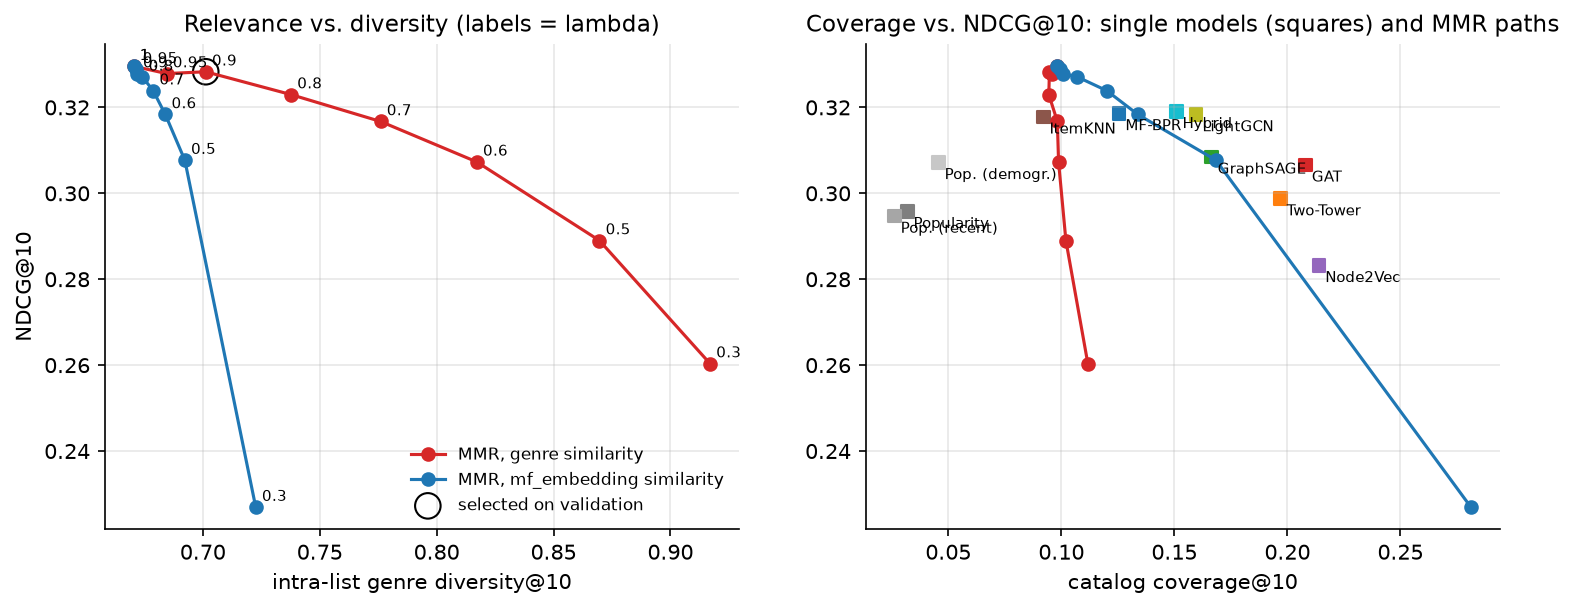

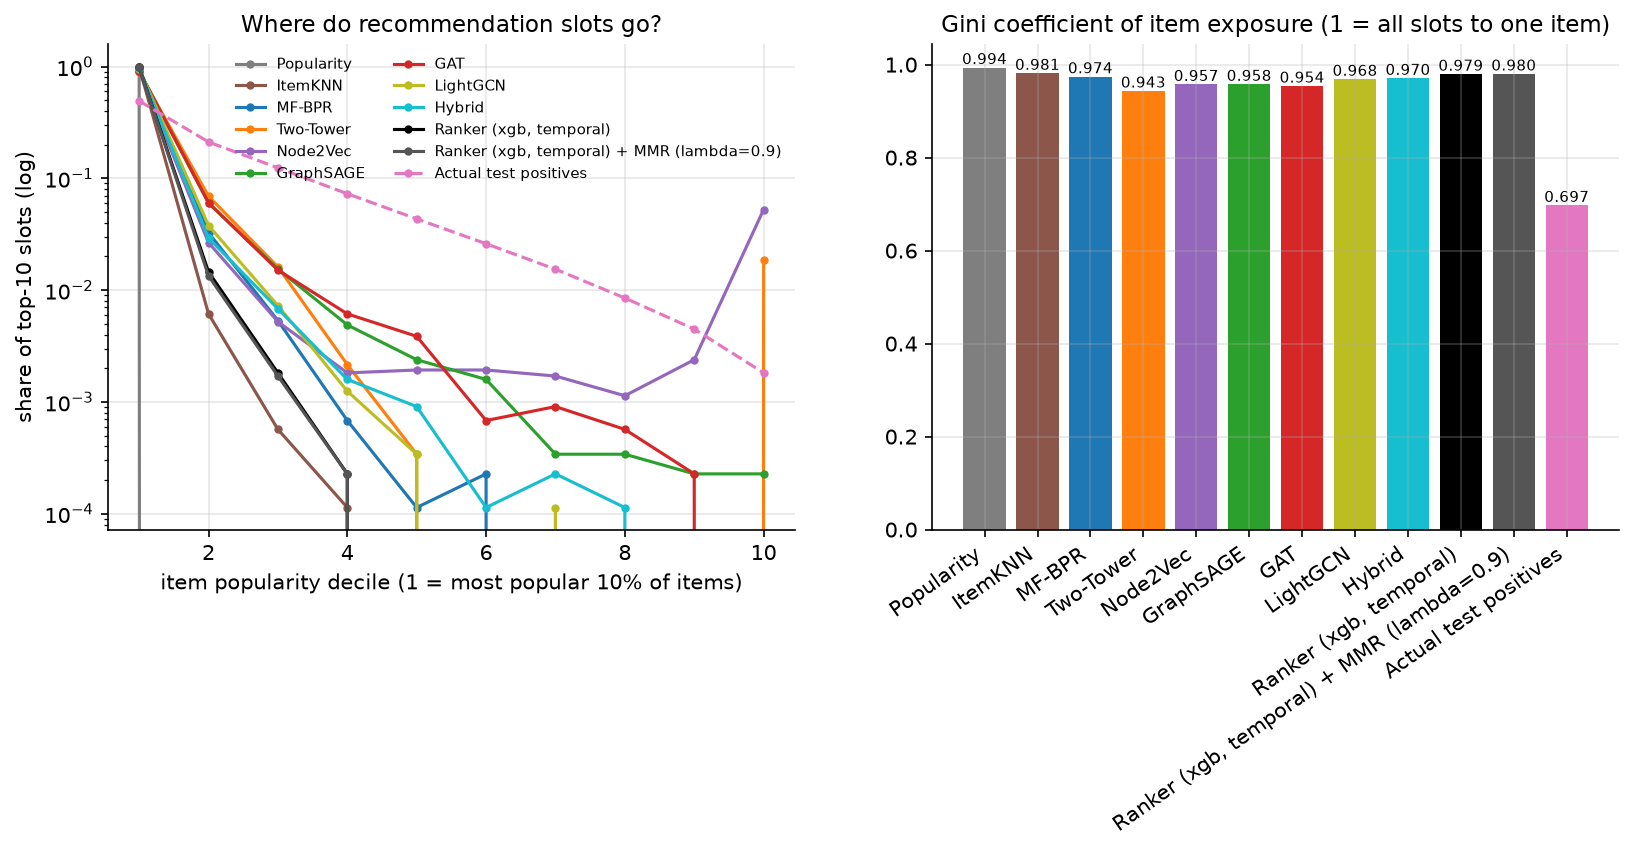

In [23]:
display(Image(F + "diversity_tradeoff.png"))
display(Image(F + "exposure_distribution.png"))

Genre MMR at lambda 0.9 is almost free (-0.4% NDCG@10 for +0.03 genre diversity) but does not change coverage or exposure, because it swaps popular movies for other popular movies. MF-embedding MMR is the one that increases coverage and novelty, at a clear NDCG cost. Every list is far more concentrated than what users actually liked (Gini 0.94-0.99 vs. 0.70); the ranker makes this a bit worse than the retriever alone.

## Link prediction view

In [24]:
pd.read_csv(T + "link_prediction_results.csv")[["model", "auc", "ap", "warm/auc", "cold/auc"]].round(4)

,model,auc,ap,warm/auc,cold/auc
0,Popularity,0.8632,0.8486,0.8550,0.8713
1,Popularity (recent),0.8603,0.8474,0.8535,0.8679
2,Popularity (demographic),0.8699,0.8578,0.8603,0.8790
3,ItemKNN,0.6921,0.6854,0.8291,0.8713
4,MF-BPR,0.8736,0.8582,0.8784,0.8705
5,Two-Tower,0.8693,0.8558,0.8680,0.8733
6,Node2Vec,0.8003,0.7957,0.8263,0.8698
7,GraphSAGE,0.8389,0.8014,0.8501,0.8693
8,GAT,0.8578,0.8280,0.8694,0.8699
9,LightGCN,0.8692,0.8537,0.8705,0.8698


AUC and recall@20 rank the models differently. Popularity has an AUC close to MF while it is the weakest model on recall, ItemKNN has the lowest AUC (many exact-zero scores tie) but a competitive top-20, and Node2Vec is worse than random on sparse users. For model selection only recall@20 / NDCG were used.

## Final table

In [25]:
pd.read_csv(T + "final_results.csv").round(4)

,Model,recall@5,recall@10,recall@20,ndcg@5,ndcg@10,ndcg@20,precision@10,map@20,mrr,coverage@10,diversity@10,novelty@10,cold_users_recall@20,sparse_users_recall@20,new_items_recall@20,train_time_s,params,retrieval_latency_ms,ranking_latency_ms
0,Popularity,0.0344,0.0601,0.1004,0.3113,0.2958,0.2726,0.2775,0.1527,0.4893,0.0318,0.6767,1.6236,0.1144,0.0900,0.0358,0.0035,0.0,NaN,NaN
1,Popularity (recent),0.0367,0.0662,0.1118,0.3107,0.2947,0.2793,0.2751,0.1552,0.4935,0.0262,0.5981,1.6908,0.1171,0.0895,NaN,0.2960,0.0,NaN,NaN
2,Popularity (demographic),0.0384,0.0664,0.1097,0.3252,0.3072,0.2873,0.2866,0.1626,0.5028,0.0456,0.6703,1.7065,0.1188,0.0983,NaN,0.0222,0.0,NaN,NaN
3,ItemKNN,0.0389,0.0669,0.1110,0.3361,0.3178,0.2934,0.2963,0.1670,0.5233,0.0920,0.6739,1.9475,0.1144,0.1161,0.0358,1.4423,0.0,NaN,NaN
4,MF-BPR,0.0419,0.0697,0.1143,0.3417,0.3186,0.2948,0.2954,0.1683,0.5147,0.1256,0.6690,1.9699,0.1122,0.1067,0.0483,45.9870,623872.0,0.2781,NaN
5,Two-Tower,0.0400,0.0692,0.1177,0.3154,0.2988,0.2827,0.2797,0.1557,0.4839,0.1969,0.6148,2.5698,0.1098,0.1314,0.1260,73.0076,712064.0,0.3160,NaN
6,Node2Vec,0.0361,0.0616,0.1040,0.3013,0.2832,0.2637,0.2629,0.1460,0.4749,0.2140,0.6788,2.7977,0.1152,0.0174,0.0379,94.0727,623744.0,0.3181,NaN
7,GraphSAGE,0.0395,0.0669,0.1123,0.3312,0.3085,0.2885,0.2860,0.1613,0.5081,0.1664,0.6527,2.2178,0.1136,0.1119,0.0373,68.0877,640384.0,0.3050,NaN
8,GAT,0.0393,0.0667,0.1139,0.3319,0.3066,0.2861,0.2847,0.1590,0.5032,0.2080,0.6489,2.3614,0.1123,0.1131,0.0437,114.7782,628160.0,0.3681,NaN
9,LightGCN,0.0413,0.0712,0.1209,0.3425,0.3183,0.2982,0.2952,0.1677,0.5198,0.1597,0.6518,2.1555,0.1121,0.1327,0.0507,54.8374,623872.0,0.3322,NaN


Final pipeline (temporal ranker + MMR): recall@20 0.1325, NDCG@10 0.328, genre diversity 0.70, about 19 ms per request on the CPU. The rows with the same-period ranker are the optimistic upper bound discussed in REPORT.md section 16.